In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv
import leidenalg

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\missegmentation'

In [87]:
Path(notebook_dir).parents[3]
os.chdir(Path(notebook_dir).parents[3])
stvelo_path = os.path.join(os.getcwd(),'SALMON','stvelo')

In [4]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
#from pipelines.utils import proportions_nuc_cyto
from pipelines.spatial_artifacts import *
from simulating.simulate_spatial_artifacts import *
from pipelines.utils import *

In [91]:
config_simulation = {'parameters':{ 'n_obs':1200,
    'n_vars':500,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':20,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.3, 0.2, -0.3, 0.3, -0.1, -0.2],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[5, 0.35, 0.34, 0.33]} }

In [92]:
simulator = Simulation3ODE(config= config_simulation) 
adata_dict = simulator.simulate_multi_obs_var(n_obs_list=[1500], n_vars_list=[500])
# adata_dict = simulator.simulation()

[5, 0.35, 0.34, 0.33]
parameters generated with the covariance matrix: [[ 0.36   0.108  0.072 -0.108]
 [ 0.108  0.36   0.108 -0.036]
 [ 0.072  0.108  0.36  -0.072]
 [-0.108 -0.036 -0.072  0.36 ]]


In [94]:
def filter_nuc_cyt(pair):
    key, value = pair
    if 'n_c_' in key:
        return True  # keep pair in the filtered dictionary
    else:
        return False  # filter pair out of the dictionary
 
adata_dict = dict(filter(filter_nuc_cyt, adata_dict.items()))
 

# 2d segmentation artifacts

In [72]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def simulate_2d_segmentation_artifacts_adata(adata, r_cell=3,section_thickness=3,
                                             n_points=100000, cut_proportion=0.5, cut_intensity=0.2,
                                             mean_cytoplasmic=0.3):
    """
    Simulate potential 2D segmentation artifacts by modeling the interaction between a sphere (nucleus)
    and a cylinder (cell) under random cuts along the z-axis, estimating misassigned points.
    
    Parameters:
    ----------
    adata : anndata.AnnData
        Anndata object containing expression data and counts for cytoplasmic and nuclear regions.
    r_sphere : float, optional
        Radius of the spherical nucleus (default is 3).
    r_cylinder : float, optional
        Radius of the cylindrical cell (default is 3).
    h_cylinder : float, optional
        Height of the cylindrical cell (default is 6).
    n_points : int, optional
        Number of random points to simulate per run (default is 100,000).
    cut_proportion : float, optional
        Fraction of cells that undergo cutting (default is 0.5).
    cut_intensity : float, optional
        Proportion of each cell’s reads that are excluded in the cut (default is 0.2).
    mean_cytoplasmic : float, optional
        Mean proportion of cytoplasm assumed to be clear- far away from nuclei and therefore, nicely identified no matter what(default is 0.3).

    Returns:
    --------
    allsim : pandas.DataFrame
        A DataFrame containing the results of the simulations.
    """
    r_cylinder=r_cell
    r_sphere=r_cell
    h_cylinder=section_thickness
    # Lists to store results for each simulation
    all_fracts = []
    all_nucleifract = []
    all_cytoprop = []
    all_nuclei_included_prop = []
    
    # Perform Monte Carlo simulations
    for cell_idx in tqdm(range(adata.shape[0])):
        
        # Randomly determine the proportion of clear cytoplasm
        clear_cytoplasm_proportion = np.random.normal(mean_cytoplasmic, 0.05)
        
        # Generate random points inside the cylinder
        z_points = np.random.uniform(-h_cylinder / 2, h_cylinder / 2, n_points)
        x_points = np.random.uniform(-r_cylinder, r_cylinder, n_points)
        y_points = np.random.uniform(-r_cylinder, r_cylinder, n_points)

        # Decide if this cell is cut based on cut_proportion
        if np.random.rand() < cut_proportion:
            # Determine the intensity of the cut for this cell (fraction of reads excluded)
            actual_cut_intensity = np.random.uniform(0, cut_intensity)
            cutting_plane_z = np.percentile(z_points, actual_cut_intensity * 100)
            
            # Calculate the proportion of nuclei included in the cut
            included_prop = np.sum(z_points < cutting_plane_z) / len(z_points)
            
            # Filter points below the cutting plane
            y_points = y_points[z_points < cutting_plane_z]
            x_points = x_points[z_points < cutting_plane_z]
            z_points = z_points[z_points < cutting_plane_z]
        else:
            # If the cell is not cut, included proportion is 100%
            included_prop = 1.0
        
        # Equation of the cylinder (x^2 + y^2 <= r_cylinder^2)
        inside_cylinder = x_points**2 + y_points**2 <= r_cylinder**2

        # Equation of the sphere (x^2 + y^2 + z^2 <= r_sphere**2)
        inside_sphere = x_points**2 + y_points**2 + z_points**2 <= r_sphere**2

        # Intersection between the cylinder and the sphere
        intersection = inside_cylinder & inside_sphere
        other_cytoplasm_points = len(z_points) * clear_cytoplasm_proportion

        # Calculate the fraction of points that are not in the intersection (exclusive to one cylinder, aka cytoplasmic counts considered as nucleic due to 2D)
        fraction_exclusive = ((n_points - np.sum(intersection)) / n_points)

        # Calculate the fraction of misassigned points relative to cytoplasm
        fraction_missassigned = ((n_points - np.sum(intersection)) / ((n_points - np.sum(intersection)) + other_cytoplasm_points))

        # Append results for this simulation
        all_fracts.append(fraction_missassigned)
        all_nucleifract.append(fraction_exclusive)
        all_cytoprop.append(clear_cytoplasm_proportion)
        all_nuclei_included_prop.append(included_prop)
    
    # Compile results into a DataFrame
    allsim = pd.DataFrame({
        'prop_true_cyto_assigned_nuclei': all_fracts,
        'prop_assigned_nuclei_belong_cyto': all_nucleifract,
        'clear_cytoplasm_proportion': all_cytoprop,
        'proportion_of_cell_imaged_in_z': all_nuclei_included_prop
    })

    adata.obs['prop_true_cyto_assigned_nuclei']= all_fracts
    adata.obs['prop_assigned_nuclei_belong_cyto']= all_nucleifract
    adata.obs['clear_cytoplasm_proportion']=all_cytoprop
    adata.obs['proportion_of_cell_imaged_in_z']=all_nuclei_included_prop
    adata2=adata.copy()
    ### modify adata.layers
    moving_part=(adata2.layers['spliced'].T * np.array(adata2.obs['prop_true_cyto_assigned_nuclei'])).T
    adata2.layers['unspliced']=adata2.layers['unspliced']+moving_part
    adata2.layers['spliced']=adata2.layers['spliced']+moving_part
    
    return adata2

In [9]:
misseg={}
for k in adata_dict.keys():
    misseg[k+'2d_segmentation_artifacts']=simulate_2d_segmentation_artifacts_adata(adata_dict[k], r_cell=3,section_thickness=6 ,cut_proportion=0.3, cut_intensity=0.5,mean_cytoplasmic=0.4)
adata_dict.update(misseg)

100%|██████████| 1500/1500 [00:06<00:00, 219.65it/s]


# missegmentation artifacts

In [95]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def simulate_missegmentation(adata, missegmentation_prob=0.3, mean_leakage=0.1, leakage_sd=0.05):
    """
    Simulate missegmentation in each cell by injecting a randomly selected expression "signature"
    (i.e., transcript counts) from the dataset, simulating partial leakage of this signature into
    each cell's expression data.

    Parameters:
    -----------
    adata : anndata.AnnData
        Anndata object containing expression data with at least 'spliced' and 'unspliced' layers.
    missegmentation_prob : float, optional
        Probability that a given cell is missegmented (default is 0.3).
    mean_leakage : float, optional
        Mean proportion of the missegmented signature to be added to the unspliced counts of each cell (default is 0.1).
    leakage_sd : float, optional
        Standard deviation for the leakage proportion, to add variability in leakage strengths (default is 0.05).

    Returns:
    --------
    adata_modified : anndata.AnnData
        A modified copy of the input adata with simulated missegmentation effects on unspliced counts.
    """
    # Copy original data to modify
    adata_modified = adata.copy()
    
    # Select a random expression signature from the existing cell population
    missegmented_signature = adata.X[np.random.randint(0, adata.shape[0]), :]
    np.random.shuffle(missegmented_signature)
    # Iterate over cells in the dataset to apply missegmentation
    leakage_proportions = []
    for cell_idx in tqdm(range(adata.shape[0])):
        # Decide if the cell is missegmented
        is_missegmented = np.random.rand() < missegmentation_prob
        
        if is_missegmented:
            # Randomly sample a leakage proportion for the missegmentation strength
            leakage_proportion = np.random.uniform( 0, 1)/mean_leakage
            leakage_proportion_nuc = np.random.uniform( 0, 1)*mean_leakage # assume leakage in nuc is half
            
            # Add a proportion of the missegmented signature to the unspliced counts for this cell
            adata_modified.layers['unspliced'][cell_idx, :] += missegmented_signature * leakage_proportion
            adata_modified.layers['spliced'][cell_idx, :] += missegmented_signature * leakage_proportion_nuc
            leakage_proportions.append(leakage_proportion)
        else:
            # If no missegmentation, set leakage proportion to zero
            leakage_proportions.append(0)
    
    # Add leakage proportions as an observation in adata
    adata_modified.obs['missegmentation_leakage_proportion'] = leakage_proportions
    adata_modified.X=adata_modified.layers['unspliced']+adata_modified.layers['spliced']
    
    return adata_modified


In [96]:
misseg={}
for k in adata_dict.keys():
    misseg[k+'missegmentation_artifacts']=simulate_missegmentation(adata_dict[k], missegmentation_prob=0.7, mean_leakage=0.8)
adata_dict.update(misseg)

100%|██████████| 1500/1500 [00:00<00:00, 71745.74it/s]


In [97]:
adata_dict

{'adata_n_c_1500obs_500genes': AnnData object with n_obs × n_vars = 1500 × 500
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'true_velocity',
 'adata_n_c_1500obs_500genesmissegmentation_artifacts': AnnData object with n_obs × n_vars = 1500 × 500
     obs: 'true_t', 'missegmentation_leakage_proportion'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'true_velocity'}

# Preprocessing

In [98]:
config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 43,
     'n_pcs': 0,
     'min_dist': 1},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic']}#,'stochastic']#,'dynamical']}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}

In [99]:
for key, adata in adata_dict.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata_dict[key] = preprocessor.preprocess_data()

adata_n_c_1500obs_500genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_1500obs_500genesmissegmentation_artifacts is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [100]:
adata_dict=keep_common_cells(adata_dict)

In [101]:
adata_dict

{'adata_n_c_1500obs_500genes': View of AnnData object with n_obs × n_vars = 1500 × 500
     obs: 'true_t', 'n_counts', 'leiden'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'true_velocity', 'Ms', 'Mu'
     obsp: 'distances', 'connectivities',
 'adata_n_c_1500obs_500genesmissegmentation_artifacts': View of AnnData object with n_obs × n_vars = 1500 × 500
     obs: 'true_t', 'missegmentation_leakage_proportion', 'n_counts', 'leiden'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'true_velocity', 'Ms', 'Mu'
     obsp: 'distances', 'connectivities'}

In [102]:
velocity_computer = Velocities(adata_dict,config_velocity)
adata_dict_velocity = velocity_computer.compute_velocities()

Using device: cuda
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/1500 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/1500 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Evaluate stuff

In [103]:
adata_dict_velocity

{'adata_n_c_1500obs_500genes_deterministic': AnnData object with n_obs × n_vars = 1500 × 500
     obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'true_velocity', 'Ms', 'Mu', 'velocity'
     obsp: 'distances', 'connectivities',
 'adata_n_c_1500obs_500genesmissegmentation_artifacts_deterministic': AnnData object with n_obs × n_vars = 1500 × 500
     obs: 'true_t', 'missegmentation_leakage_proportion', 'n_counts', 'leiden', 'velocity_self_transition'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'vel

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


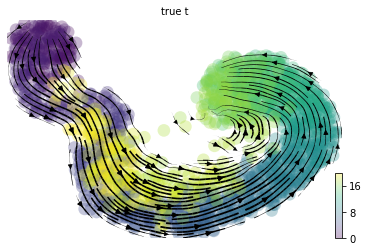

In [104]:
 
ad2=adata_dict_velocity['adata_n_c_1500obs_500genes_deterministic']
scv.pl.velocity_embedding_stream(ad2, basis='umap',color='true_t')

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


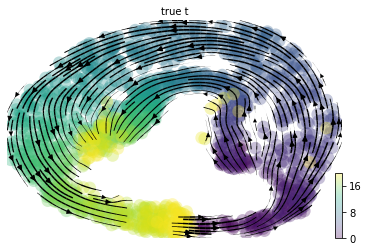

In [105]:
ad2=adata_dict_velocity['adata_n_c_1500obs_500genesmissegmentation_artifacts_deterministic']
scv.pl.velocity_embedding_stream(ad2, basis='umap',color='true_t')

ValueError: color key is invalid! pass valid observation annotation or a gene name

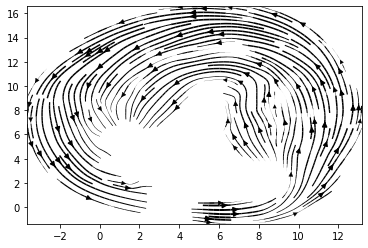

In [106]:
scv.pl.velocity_embedding_stream(ad2, basis='umap',color='prop_true_cyto_assigned_nuclei',cmap='Blues')

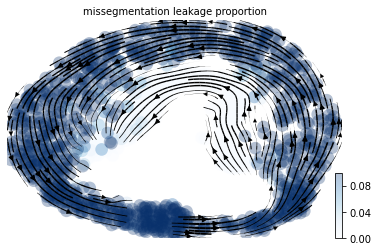

In [108]:
scv.pl.velocity_embedding_stream(ad2, basis='umap',color='missegmentation_leakage_proportion',cmap='Blues')

# Missegmentation artifacts

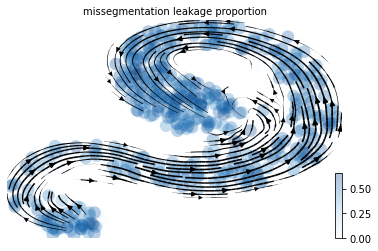